# Statistical Analysis

In this notebook we will explore some of the statistical techniques commonly used in particle physics analyses, specifically when searching for new particles. The methods we will use are based on likelihoods and are similar to those used in analyses at the Large Hardon Collider (LHC).

We will analyze results from multiple signal regions and learn how to:

- model events counts using the Poisson distribution
- construct a likelihood function for signal and background predictions
- introduce the signal strength parameter and how to include uncertainties through nuisance parameters
- build test statistics based on the log-likelihood ratio
- compute p-values and covert them to significance while learning about what is needed for discovery tests
- use asymptotic approximations to efficiently and quickly evaluate these values
- set exclusion limits using $CL_s$ methods

By the end of the notebook, we will apply these methods to a simplified supersymmetry (SUSY) search. We will calculate the observed and expected exclusion limits for different signal model mass hypotheses and produce an exclusion contour similar to those seen in SUSY analyses. 

### Physics Process in this Notebook

The data used here comes from a SUSY search with a focus on chargino-neutralino production in proton-proton collisions. In this model, the final state has two charged leptons and missing transverse energy. The lightest neutralinos would contribute to the missing transverse energy in this model. Each signal model we will test corresponds to a specific pair of particle masses: the mass of the chargino/neutralino and the mass of the lightest neutralino.

If you'd like to learn more about this analysis and how the results used here were produced, check out [this notebook](https://github.com/emilypuchala/MasterThesis/blob/main/supersymmetry_analysis.ipynb) .

## Using a Jupyter Notebook

This notebook provides a way to analyze the data and perform an analysis all in a single file. 

### Running the Notebook:
- To run the entire notebook, click Cell $\rightarrow$ Run All in the top menu.
- To run an individual cell, click Cell $\rightarrow$ Run Cells in the top menu, or use the Shift+Enter keyboard shortcut.

#### Possible Errors:
If a cell produces an error or unexpected result, try to:
1. Read the error message carefully (sometimes something as simple as forgetting a comma is all it takes to produce an error)
2. Revert the notebook to your last checkpoint (essentially a save point) and run the cell again.

Run the next cell to install and update any required packages. 

In [1]:
# only need to run this cell the first time you open this notebook on your computer
# import sys

## update the pip package installer
#!{sys.executable} -m pip install --upgrade --user pip
## install required packages
#!{sys.executable} -m pip install --upgrade --user numpy matplotlib pandas scipy

Run the next cell to load all the python libraries and packages that will help us run our analysis.

In [2]:
import os       # loading / reading file 
import os.path  # loading / reading file

import pandas as pd # working with dataframes
import numpy as np  # numerical calculations

import matplotlib.pyplot as plt     # plotting
import matplotlib.lines as mlines   # plotting lines
from matplotlib.lines import Line2D # plotting lines
from matplotlib.ticker import LogLocator, NullFormatter, AutoMinorLocator # plotting tick marks

from scipy.stats import norm, poisson   # statistical function
from scipy.interpolate import interp1d  # 2d grid plotting
from scipy.interpolate import griddata  # 2d grid plotting
from scipy.optimize import minimize     # minimize function
from scipy.optimize import brentq       # root finding function

## Loading the Data
Before we can perform our statistical analysis, we need some results. The results we will use here have been obtained from a previously completed analysis and are loaded as pre-defined lists for simplicity. This allows us to run the full statistical analysis without relying on any external files.

### Pre-defined lists
For each signal model we have:
- ```m_chargino``` : mass of the chargino/neutralino
- ```m_neutralino``` : mass of the lightest neutralino
- ```cross_section``` : theoretical or production cross section in picobarn(pb)

For each signal region (_intSR and _highSR), we have:
- ```n_obs``` : observed data events
- ```background``` : background event yields
- ```background_error``` : statistical uncertainty on the background event yields
- ```signal``` : signal event yields
- ```signal_error``` : statistical uncertainty on the signal event yields

In this example, we will consider two signal regions (intermediate and high), which will be the two bins in our multi-bin analysis. These two signal regions are different depending on the missing transverse energy selection requirements that were applied in the analysis. Since the two regions are orthogonal, meaning they do not overlap, they can safely be combined into one region.


In [3]:
# these values are the same between signal regions
m_chargino = [200.0, 250.0, 250.0, 300.0, 300.0, 350.0, 350.0, 350.0, 400.0, 400.0, 400.0, 450.0, 450.0, 450.0, 450.0, 500.0, 500.0, 500.0, 500.0, 550.0, 550.0, 550.0, 550.0, 550.0, 600.0, 600.0, 600.0, 600.0, 600.0, 650.0, 650.0, 650.0, 650.0, 650.0, 650.0, 700.0, 700.0, 700.0, 700.0, 700.0, 700.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 800.0, 800.0, 800.0, 800.0, 800.0, 800.0, 900.0, 900.0, 900.0, 900.0, 900.0, 900.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1100.0, 1100.0, 1100.0, 1100.0, 1100.0, 1100.0, 1200.0, 1200.0, 1200.0, 1200.0, 1200.0, 1200.0]
m_neutralino = [0.0, 0.0, 100.0, 0.0, 100.0, 0.0, 100.0, 200.0, 0.0, 100.0, 200.0, 0.0, 100.0, 200.0, 300.0, 0.0, 100.0, 200.0, 300.0, 0.0, 100.0, 200.0, 300.0, 400.0, 0.0, 100.0, 200.0, 300.0, 400.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0]
cross_section = [1.8074, 0.782514, 0.782514, 0.386946, 0.386946, 0.209458, 0.209458, 0.209458, 0.121027, 0.121027, 0.121027, 0.073446, 0.073446, 0.073446, 0.073446, 0.0463569999999999, 0.0463569999999999, 0.0463569999999999, 0.0463569999999999, 0.030171, 0.030171, 0.030171, 0.030171, 0.030171, 0.0201399999999999, 0.0201399999999999, 0.0201399999999999, 0.0201399999999999, 0.0201399999999999, 0.013731, 0.013731, 0.013731, 0.013731, 0.013731, 0.013731, 0.0095109999999999, 0.0095109999999999, 0.0095109999999999, 0.0095109999999999, 0.0095109999999999, 0.0095109999999999, 0.006694, 0.006694, 0.006694, 0.006694, 0.006694, 0.006694, 0.0047589999999999, 0.0047589999999999, 0.0047589999999999, 0.0047589999999999, 0.0047589999999999, 0.0047589999999999, 0.002496, 0.002496, 0.002496, 0.002496, 0.002496, 0.002496, 0.001344, 0.001344, 0.001344, 0.001344, 0.001344, 0.001344, 0.00074, 0.00074, 0.00074, 0.00074, 0.00074, 0.00074, 0.000417, 0.000417, 0.000417, 0.000417, 0.000417, 0.000417]


# High Signal Region
n_obs_highSR = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
background_highSR = [0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864, 0.64864]
background_error_highSR = [0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354, 0.55354]
signal_highSR = [0.71059, 1.36905, 0.45915, 5.60765, 1.41294, 8.45837, 5.12465, 0.39813, 7.8333, 6.31006, 1.23977, 6.2189, 5.62943, 2.64827, 0.1292, 5.30188, 4.7272, 3.19098, 0.91081, 3.57026, 3.36717, 2.88976, 1.47338, 0.03183, 2.45343, 2.42814, 2.17234, 1.65162, 0.50858, 1.80893, 1.79306, 1.6958, 1.42361, 0.88302, 0.01749, 1.29186, 1.22156, 1.29924, 1.14417, 0.81666, 0.23401, 0.85087, 0.82999, 0.82812, 0.86513, 0.72482, 0.45126, 0.62383, 0.62675, 0.62984, 0.64526, 0.62504, 0.46556, 0.2816, 0.2786, 0.28467, 0.27191, 0.31541, 0.32711, 0.1273, 0.13104, 0.14252, 0.16484, 0.16186, 0.17888, 0.05992, 0.06068, 0.06054, 0.07274, 0.08204, 0.08931, 0.02991, 0.02893, 0.03179, 0.03497, 0.04143, 0.0438]
signal_error_highSR = [0.2856, 0.35206, 0.22677, 0.66891, 0.34147, 0.60427, 0.47293, 0.13699, 0.45505, 0.40634, 0.17351, 0.32422, 0.3082, 0.20507, 0.04525, 0.24342, 0.22498, 0.18025, 0.09527, 0.16235, 0.15995, 0.14517, 0.10004, 0.01472, 0.11162, 0.11003, 0.10634, 0.08917, 0.0483, 0.08243, 0.08032, 0.07783, 0.06919, 0.05407, 0.00684, 0.05773, 0.05609, 0.05777, 0.05434, 0.04413, 0.02238, 0.04023, 0.03963, 0.03888, 0.03961, 0.03528, 0.02763, 0.02939, 0.02934, 0.02955, 0.02948, 0.02803, 0.02385, 0.01485, 0.01454, 0.01461, 0.01402, 0.01497, 0.0151, 0.0074, 0.00757, 0.00778, 0.0085, 0.00827, 0.0086, 0.00383, 0.00392, 0.00384, 0.00419, 0.00447, 0.00452, 0.00207, 0.00205, 0.00216, 0.00225, 0.00247, 0.00249]


# Intermediate(int) Signal Region
n_obs_intSR = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
background_intSR = [1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988, 1.3988]
background_error_intSR = [0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261, 0.47261]
signal_intSR = [5.83352, 15.27523, 3.07189, 12.97, 10.67102, 8.29024, 7.88503, 1.77499, 5.32137, 4.5451, 4.1158, 2.9531, 2.97978, 2.88594, 0.75538, 1.80851, 1.60736, 1.59328, 1.54707, 0.9608, 0.99584, 1.07095, 1.26269, 0.27977, 0.48699, 0.55984, 0.56186, 0.7959, 0.71699, 0.37833, 0.33627, 0.36167, 0.46491, 0.52435, 0.20752, 0.21719, 0.17922, 0.2399, 0.25778, 0.34191, 0.33259, 0.14999, 0.14319, 0.17074, 0.17092, 0.22777, 0.2882, 0.08958, 0.09441, 0.08838, 0.11948, 0.14646, 0.18909, 0.03801, 0.03942, 0.04023, 0.04264, 0.05664, 0.07001, 0.01105, 0.01375, 0.01288, 0.01383, 0.01811, 0.02706, 0.00388, 0.00539, 0.00675, 0.00634, 0.00771, 0.0093, 0.00195, 0.00222, 0.00302, 0.00301, 0.00356, 0.00488]
signal_error_intSR = [0.85962, 1.14474, 0.49581, 0.99276, 0.89017, 0.59069, 0.57962, 0.26725, 0.37636, 0.34536, 0.31936, 0.21761, 0.22334, 0.21183, 0.10259, 0.14306, 0.13277, 0.12496, 0.1243, 0.08477, 0.08674, 0.08714, 0.09198, 0.0405, 0.04916, 0.05417, 0.05282, 0.06217, 0.05625, 0.03672, 0.03564, 0.03676, 0.04075, 0.04073, 0.02507, 0.02426, 0.02184, 0.02509, 0.02586, 0.02753, 0.02735, 0.01739, 0.01657, 0.01819, 0.01764, 0.02003, 0.02145, 0.01134, 0.01167, 0.01077, 0.0128, 0.01355, 0.01512, 0.00536, 0.00531, 0.00551, 0.0055, 0.00639, 0.00714, 0.0022, 0.00264, 0.00246, 0.00235, 0.00272, 0.00336, 0.00094, 0.00115, 0.0013, 0.00127, 0.00127, 0.00155, 0.00059, 0.00054, 0.00067, 0.00067, 0.0007, 0.00083]

Let's put all these arrays into a single data frame(df) called ```df_data``` so it's easier to work with. We will use this data frame to access the values in our calculations and add any values we compute. 

In [4]:
# define high region
df_high = pd.DataFrame({
    "m_chargino": m_chargino,
    "m_neutralino": m_neutralino,
    "cross_section": cross_section,
    "background": background_highSR,
    "background_error": background_error_highSR,
    "n_obs": n_obs_highSR,
    "signal": signal_highSR,
    "signal_error": signal_error_highSR,
})

# define intermediate region
df_int = pd.DataFrame({
    "m_chargino": m_chargino,
    "m_neutralino": m_neutralino,
    "cross_section": cross_section,
    "background": background_intSR,
    "background_error": background_error_intSR,
    "n_obs": n_obs_intSR,
    "signal": signal_intSR,
    "signal_error": signal_error_intSR,
})

# create a single combined dataframe with both regions
df_data = pd.merge(
    df_high,
    df_int,
    on=["m_chargino", "m_neutralino", "cross_section"], # same for both regions
    suffixes=("_highSR", "_intSR") # add identifier for each region's values
)

By printing the first few rows of our data table, we can see what numbers we are working with for each of our signal models. Let's make sure our dataframe looks correct by running the next cell:

In [5]:
pd.set_option('display.max_columns', None) # display all available columns
df_data.head(15) # print first 15 rows of the dataframe

,m_chargino,m_neutralino,cross_section,background_highSR,background_error_highSR,n_obs_highSR,signal_highSR,signal_error_highSR,background_intSR,background_error_intSR,n_obs_intSR,signal_intSR,signal_error_intSR
0,200.0,0.0,1.807400,0.64864,0.55354,0,0.71059,0.28560,1.3988,0.47261,1,5.83352,0.85962
1,250.0,0.0,0.782514,0.64864,0.55354,0,1.36905,0.35206,1.3988,0.47261,1,15.27523,1.14474
2,250.0,100.0,0.782514,0.64864,0.55354,0,0.45915,0.22677,1.3988,0.47261,1,3.07189,0.49581
3,300.0,0.0,0.386946,0.64864,0.55354,0,5.60765,0.66891,1.3988,0.47261,1,12.97000,0.99276
4,300.0,100.0,0.386946,0.64864,0.55354,0,1.41294,0.34147,1.3988,0.47261,1,10.67102,0.89017
5,350.0,0.0,0.209458,0.64864,0.55354,0,8.45837,0.60427,1.3988,0.47261,1,8.29024,0.59069
6,350.0,100.0,0.209458,0.64864,0.55354,0,5.12465,0.47293,1.3988,0.47261,1,7.88503,0.57962
7,350.0,200.0,0.209458,0.64864,0.55354,0,0.39813,0.13699,1.3988,0.47261,1,1.77499,0.26725
8,400.0,0.0,0.121027,0.64864,0.55354,0,7.83330,0.45505,1.3988,0.47261,1,5.32137,0.37636
9,400.0,100.0,0.121027,0.64864,0.55354,0,6.31006,0.40634,1.3988,0.47261,1,4.54510,0.34536


Now our table is a little easier to read, compared to those long lists of numbers we loaded, and we can see what data we have for each of our signal models. 

**What do you think?**
- How many background events and observed events do we have in our high signal region? What about our intermediate region?
- What number of events are predicted for each of our signal models? How do these predications compare to the observed events?
- What do you notice about the number of signal events in the high versus the intermediate signal region? Why do you think this difference occurs?
- As the chargino mass of signal models increases, does the number of predicted signal events decrease, increase, or stay the same? What do you think causes this trend? How might the cross section influence this behavior?

## Using your own data
You can, of course, load your own ```.txt``` or ```.csv``` file containing results from your own analysis if you prefer.

Some important things to keep in mind if you choose this option:

- To avoid accidentally mixing the results from two different analyses, do not run the previous two Python cells.
- The variable names in your file might be different from those defined here and used throughout the analysis (be sure to check and update these names accordingly).
- The exclusion plots in this notebook assume a two-dimensional analysis (scanning over two mass parameters).

An example of how you could load your own data is included (but commented out) in the next cell.

**Try it yourself!** After going through the workflow in this example, try loading your own data and running your own statistical analysis!

In [6]:
# # import file 
# path = os.path.expanduser("~/your_directory_name/path_to_your_file.csv") # path to your file
# df_your_reulsts = pd.read_csv(path) # open and read the file

# # define variables for your loaded file

# # mass
# m_chargino = df_your_reulsts["mass_chargino"].values
# m_neutralino = df_your_reulsts["mass_neutralino"].values

# # cross section
# cross_section = df_your_reulsts["xsec"].values

# # number of observed data events
# n_obs = df_your_reulsts["number_observed"].values

# # number of background events and error
# background = df_your_reulsts["background"].values
# background_error = df_your_reulsts["background_statistical_error"].values

# # number of signal events and error
# signal = df_your_reulsts["signal"].values 
# signal_error = df_your_reulsts["signal_statistical_error"].values


## Poisson Distribution
In particle physics analyses, we count the number of observed events, $n$. If the expected events is $\lambda$, then the probability of observing $n$ events follows a Poisson distribution.

The expected number of events can be written as:
$$\lambda = s+b$$
where:
- $s$ is the expected signal yield
- $b$ is the expected background yield.

 
The probability of observing $n$ events is then:
$$ P(n;\lambda) = \frac{\lambda^n e^{-\lambda}}{n!}$$

where:
- $n$ = the observed events
- $\lambda$ = expected events.

This Poisson distribution forms the starting point of our statistical analysis. We can visualize the Poisson distribution in the next cell:

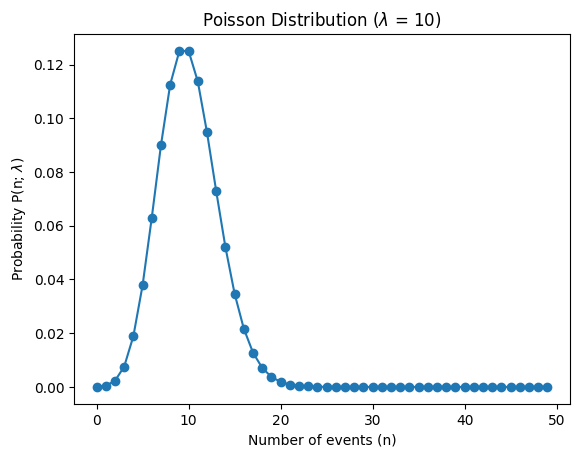

In [7]:
# visualize the Poisson distribution
events = np.arange(0, 50) # possible observed event counts
lam = 10 # lambda (expected events)

# Poisson distribution calculation
probability = poisson.pmf(events, lam)

# plot the distribution
plt.figure()
plt.plot(events, probability, marker='o')
plt.xlabel("Number of events (n)")
plt.ylabel("Probability P(n; $\lambda$)")
plt.title(f"Poisson Distribution ($\lambda$ = {lam})")
plt.show()

**Try it yourself!** change the value of ```lam``` and observe how the distribution changes or try plotting multiple values of $\lambda$ on the same plot.

## Likelihood-based Counting Experiment
To compare our data with different signal hypotheses, we construct a likelihood function, which quantifies how compatible a given signal hypothesis is with the observed data.

For a single counting experiment, the likelihood under a signal hypothesis $s$ is:
$$L(s) = P(n|s+b)$$

where $n$ is the number of observed events and $b$ is the expected background.

## Multiple Bins (Signal Regions)
In many analyses, data are divided into several bins or signal regions, each containing its own observed event count and predicted signal and background contributions.

For bin $i$:
- $n_i$ = observed events
- $s_i$ = expected signal 
- $b_i$ = expected background

The expected number of events is then:
$$ \lambda_i = s_i + b_i$$

The number of observed events follows a Poisson distribution, where for multiple bins this is generally written as:
$$P(n_i|\lambda_i) = \frac{\lambda_i^{n_i} e^{-\lambda_i}}{n_i!}$$

This is the same structure as in our previous Poisson distribution equation but now applied to each bin.

The full likelihood across all bins is then the product of the Poisson probabilities for each bin:
$$ L(\mu) = \prod_{i=1}^{N} P(n_i | \lambda_i)$$


## Signal Strength Parameter
To test different signal hypotheses, we introduce a signal strength parameter $\mu$ (in this code we will call this variable ```mu```) which scales the expected signal prediction.
$$ \lambda_i = \mu s_i + b_i$$

This likelihood then becomes:
$$L(\mu) = \prod_{i=1}^{N} P(n_i | \mu s_i + b_i)$$

or more explicitly:
$$L(\mu) = \prod_{i=1}^{N} \frac{(\mu s_i + b_i)^{n_i} e ^{-(\mu s_i + b_i)}}{n_i!} $$

The parameter $\mu$ is a free parameter, determined by maximizing the likelihood function. The value that maximizes the likelihood corresponds to the signal strength that best describes the observed data. 

## Log-Likelihood
In practice, it's often easier to work with the log-likelihood:
$$\ln L(\mu) = \sum_{i=1}^{N} \ln P(n_i | \mu s_i + b_i)$$

or when we substitute the Poisson probability:
$$\ln L(\mu) = \sum_{i=1}^N [n_i \ln (\mu s_i + b_i) - (\mu s_i + b_i)] + \text{constant}$$

Since the factorial term $n_i!$ is not dependent on $\mu$, it cancels when defining the likelihood ratio, so we can ignore it here. 

## Including Uncertainties
So far, we have assumed the signal and background predictions are known exactly and ignored uncertainties. In reality, they are affected by several sources of uncertainty which are typically divided into:
- statistical uncertainties
   - fluctuations in the event yields
   - these scale approximately as ($\sqrt{N}$)
- systematic uncertainties
   - from detector measurement performance (reconstruction or identification efficiency, luminosity, etc.)
   - from theoretical modelling (Monte Carlo generators, scale factors, etc.) 

If we ignore these effects, the true uncertainty in our measurement would be underestimated, and we could potentially overstate the significance of the signal. 

## Nuisance Parameters
We incorporate uncertainties by introducing nuisance parameters ($\boldsymbol{\theta}$). These parameters modify the predicted signal and background yields:
$$ \lambda_i(\mu, \boldsymbol{\theta}) = \mu s_i(\boldsymbol{\theta}) + b_i(\boldsymbol{\theta})$$

In this example, we have:
- a shared nuisance parameter $\theta$ which modifies both the signal and background normalization (in our example, this shared nuisance parameter is our systematic uncertainty).
- independent nuisance parameters, $\gamma_i$, which describe per-bin statistical uncertainties on the background event yields using a log-normal approximation. 

To make sure the prediction yields remain positive values, we model these as:
$$ b_i (\boldsymbol{\theta}) = b_i e^{\delta \theta} e^{\sigma_i \gamma_i}$$
$$ s_i (\boldsymbol{\theta}) = s_i e^{\delta \theta} $$

where 
- $\delta$ is the relative correlated systematic uncertainty
- $\sigma_i = \frac{\Delta b_i}{b_i}$ is the relative statistical uncertainty in bin $i$.




## Likelihood with Constraints
The full likelihood becomes:
$$L(\mu, \boldsymbol{\theta}) = \prod_{i=1}^{N} P(n_i | \lambda_i(\mu, \boldsymbol{\theta})) C(\boldsymbol{\theta})$$

The term $C(\boldsymbol{\theta})$ constrains the nuisance parameters. We typically assume Gaussian constraints:
$$C(\boldsymbol{\theta}) = \mathcal{N}(\theta; 0,1) \prod_i \mathcal{N}(\gamma_i; 0,1)$$

which penalizes large deviations from the nominal predictions.

### Profiling Nuisance Parameters
We are mainly interested in the signal strength $\mu$, not the nuisance parameters. To handle this, we profile them, meaning for a fixed value of $\mu$, we choose the nuisance parameters that maximize the likelihood:

$$ \hat{\hat{\boldsymbol{\theta}}} = \underset{\boldsymbol{\theta}}{\text{arg max }} L(\mu, \boldsymbol{\theta})$$

In other words, for each assumed signal strength, the nuisance parameters are adjusted to provide the best fit to the observed data. 

The overall best-fit parameters are:
$$ (\hat{\mu}, \hat{\boldsymbol{\theta}}) = \underset{\mu \geq 0, \boldsymbol{\theta}}{\text{arg max }} L(\mu, \boldsymbol{\theta})$$

Because we have multiple bins and multiple nuisance parameters, these estimators are determined by maximizing the full likelihood function and are typically found numerically (which is what we will do in the code below). 

 


In [8]:
# log-likelihood for a multiple-bin counting experiment
def log_likelihood(n_list, mu, s_list, b_list, b_stat_err_list, theta):
 
    # nuisance parameters (uncertainties)
    shared_nuisance = theta[0]  # global systematic parameter
    gamma_statistical_nuisance  = theta[1:]  # per-bin statistical nuisance parameters

    # enforce one sided constraint, mu >= 0
    if mu < 0:
        return -np.inf # optimizer rejects this condition

    # initialize total log-likelihood
    log_likelihood_value = 0.0

    # loop through all the bins in the analysis
    for i in range(len(n_list)):

        # compute relative statistical uncertainty for background
        if b_list[i] > 0:
            stat_uncertainty = b_stat_err_list[i] / b_list[i]
        else:
            stat_uncertainty = 0.0 # zero if uncertainties not defined

        # compute modified background and signal predictions
        background_prediction = b_list[i] * np.exp(systematic_uncertainty * shared_nuisance) * np.exp(stat_uncertainty * gamma_statistical_nuisance[i])
        signal_prediction = s_list[i] * np.exp(systematic_uncertainty * shared_nuisance)
        
        # total expected yield for this bin
        total_expected = background_prediction + (mu * signal_prediction)
        total_expected = max(total_expected, 1e-12) # avoid NaNs if division by zero (set to small number close to zero)

        # add Poisson log-likelihood for this bin
        log_likelihood_value += n_list[i] * np.log(total_expected) - total_expected

        # add Gaussian constraint for statistical nuisance paramter
        log_likelihood_value -= 0.5 * gamma_statistical_nuisance[i]**2

    # add Gaussian constraint for the shared nuisance parameter
    log_likelihood_value -= 0.5 * shared_nuisance**2

    return  log_likelihood_value



## Hypothesis Testing
To test whether a signal is present in the data, we compare two hypotheses:
- $H_0$: background-only hypothesis ($\mu = 0$)
- $H_1$: signal + background hypothesis ($\mu > 0$)

The background only hypothesis corresponds to the prediction of the Standard Model, while the signal + background hypothesis would suggest some additional process (potentially new physics!) contributes to the observed events. To quantify how compatible the observed data is with these hypotheses, we use a likelihood ratio test statistic. 

## Test Statistic
The general likelihood ratio test statistic is
$$q_\mu= -2 \ln \frac{L(\mu, \hat{\hat{\boldsymbol{\theta}}}(\mu))} {L(\hat{\mu}, \hat{\boldsymbol{\theta}})}$$
where
- $L(\mu,\hat{\hat{\boldsymbol{\theta}}}(\mu))$ is the likelihood for a fixed signal strength with nuisance parameters that maximize the likelihood for that value of $\mu$
- $L(\hat{\mu},\hat{\boldsymbol{\theta}})$ is the maximum likelihood obtained by fitting both the signal strength and nuisance parameters to the data.

The denominator represents the best possible description of the data, while the numerator evaluates how well a specific signal hypothesis fits the observations. 

## Discovery Test Statistic
To test the background-only hypothesis we set $\mu = 0$, so our test statistic becomes:
$$q_0 = -2 \ln \frac{L(\mu = 0, \hat{\hat{\boldsymbol{\theta}}}(0))} {L(\hat{\mu}, \hat{\boldsymbol{\theta}})}$$
where
- $\hat{\hat{\boldsymbol{\theta}_0}}$ are the nuisance parameters that maximise the likelihood under the background-only hypothesis
- ($\hat{\mu}, \hat{\boldsymbol{\theta}}$) are the global maximum likelihood estimators

A one-sided constraint on the test statistic is applied where,
$$ q_0 = 
\begin{cases}
-2 \ln \lambda(0) & \text{if } \hat{\mu} \ge 0 \\
0 & \text{if } \hat{\mu} < 0
\end{cases}
$$
meaning the signal strength parameter cannot be negative.

The value of the test statistic indicates how compatible the data are with the tested hypothesis:
- small $q_0$: data is compatible with the hypothesis
- large $q_0$: the hypothesis is unlikely based on the data. 

The fitted signal strength, $\hat{\mu}$, is the value that makes the observed data most probable under our complete statistical model and considers all uncertainties. 



In [9]:
# signal + background hypothesis test statistic
def q_mu(n_list, b_list, s_list, mu, b_stat_err_list):

    n_bins = len(n_list) # number of bins to determine how many nuisance parameters exist

    # global maximum likelihood estimator (mu is a free parameter)
    def negative_log_likelihood_free(all_parameters):
        mu_fit = all_parameters[0] # signal strength mu
        theta  = all_parameters[1:] # nuisance parameters
        
        # negative log-likelihood for the optimizer
        return -log_likelihood(n_list, mu_fit, s_list, b_list, b_stat_err_list, theta)

    # initial guesses for the optimizer parameters (structure: mu, global nuisance, statistical nuisance)
    initial_guess_free = [1.0] + [0.0] * (1 + n_bins)  
    
    # bounds for optimizer (if mu >=0 the nuisance parameters are not constrained)
    paramter_bounds_free = [(0, None)] + [(None, None)] * (1 + n_bins)

    # run the minimization to find the best fit parameter
    result_free = minimize(
        negative_log_likelihood_free,
        x0=initial_guess_free,
        bounds=paramter_bounds_free,
        method="L-BFGS-B" # limited-memory Broyden–Fletcher–Goldfarb–Shanno with Bounds
    )

    # if optimizer fails, return NaN
    if not result_free.success:
        return np.nan

    # fitted signal strength (mu_hat)
    mu_hat = result_free.x[0]
    # Convert minimized negative log-likelihood to log-likelihood
    log_likelihood_hat = -result_free.fun

    # conditional maximum likelihood estimator (mu is a fixed parameter)
    def negative_log_likelihood_fixed(theta):
        return -log_likelihood(n_list, mu, s_list, b_list, b_stat_err_list, theta)

    # initial guesses for nuisance parameters
    initial_guess_fixed = [0.0] * (1 + n_bins)

    # run minimization with fixed mu
    result_fixed = minimize(
        negative_log_likelihood_fixed,
        x0=initial_guess_fixed,
        method="L-BFGS-B"
    )
    # if optimizer fails, return NaN
    if not result_fixed.success:
        return np.nan

    # log-likelihood for the fitted mu
    loglikelihood_mu = -result_fixed.fun

    # apply the one-sided constraint
    if mu_hat > mu:
        return 0.0

    # compute likelihood ratio test statistic
    return -2.0 * (loglikelihood_mu - log_likelihood_hat)


## p-values
A p-value quantifies how compatible the observed data are with the null hypothesis. In our case, the null hypothesis ($H_0$) is the background-only hypothesis, meaning the observed data is fully explained by the known background processes and no signal is present.

The p-value is defined as:
$$p_0 = P(q_0 \geq q_0^{obs} | H_0)$$

This is the probability of obtaining a test statistic($q_0$) which is at least as large as the observed ($q_0^{obs}$) when assuming the background-only hypothesis is true. 
- large p-values: the data is compatible with the background
- small p-values: the observed data are unlikely under the background-only hypothesis.

## Significance
In particle physics, it is common to express the p-value as a significance ($Z$), measured in units of standard deviations of a normal distribution.
$$Z = \Phi ^{-1} (1 - p_0)$$
where $\Phi ^{-1}$ is the inverse cumulative distribution of a standard Gaussian function. This converts the p-values to the number of Gaussian standard deviations.


## Asymptotic Approximation
For large datasets, Wilks theorem and the Wald approximation allow us to approximate the distribution of the test statistic. For this approximation, the p-value becomes
$$p_0 = 1 - \Phi (\sqrt(q_0))$$
and the significance simplifies to
$$Z = \sqrt(q_0)$$

In [10]:
# compute p0-value  for the background only hypothesis (mu = 0)
def p0_value(n_list, b_list, s_list, b_stat_err_list):

    # compute test statistic for mu = 0
    q0 = q_mu(n_list, b_list, s_list, 0.0, b_stat_err_list)

    # return NaN if test statistic cannot be computed
    if np.isnan(q0):
        return np.nan

    # convert test statistic to significance
    Z0 = np.sqrt(max(q0, 0.0)) # ensure q0 >= 0 for stability
    return norm.sf(Z0) # survival function

## Claiming Discovery
Once the p-value is computed, we can interpret this result. In high-energy particle physics, a discovery is typically claimed when the significance is greater than $5\sigma$, which corresponds to a p-value of $p_0 \leq 2.87 \cdot 10^{-7}$.

This means the probability that any observed excess arising from statistical fluctuations of the background is extremely small. 

These high thresholds are needed so a discovery is not wrongly claimed due to statistical fluctuations in the data. The thresholds are largely the conventions used by particle physics experiments. This [cheat sheet](https://cds.cern.ch/record/2875522/files/Statistical%20Significance%20-%20ATLAS%20Cheat%20Sheet.pdf ) gives a brief overview of statistical significance in LHC data.

If the significance does not reach the discovery threshold, our next step is usually to set exclusion limits on the signal model.

## Exclusion Limits
While the discovery test asks if a signal is present, the exclusion test determines which signal models are not compatible with the observed data.

For a given signal strength $\mu$:
- if the hypothesis is not compatible with the data, it is excluded
- if the hypothesis is compatible with the data, it is not excluded.
    - this also includes cases where we do not have enough information to assess the compatibility

Excluding a signal does not imply that another signal is present; it just means that this particular predicted signal model is unlikely based on our data. 


## The $CL_s$ Method
In a frequentist framework, exclusion limits are commonly set using the confidence level ($CL_s$) method, which compares the signal plus background and background-only hypotheses.

For a given signal strength $\mu$ we define:

1. Signal + background confidence level:
$$CL_{s+b} =  P(q_\mu \geq q_\mu^{obs} | \mu)$$

2. Background-only confidence level:
$$CL_{b} =  P(q_\mu \geq q_\mu^{obs} | 0)$$

The modified confidence level is then:
$$CL_{s} = \frac{CL_{s+b}}{CL_{b}}$$

This prevents excluding signal models where our experiment has little sensitivity to them. A signal hypothesis is considered excluded at the 95% confidence level if
$$CL_{s} < 0.05$$

This threshold is widely used in high-energy physics searches. In practice, we scan different values of the signal strength and determine the largest value that satisfies this condition. This is our upper exclusion limit. 

## Asymptotic Approximation
The probability definitions used above are the exact or explicit definitions but can be computationally expensive. Instead, we will use asymptotic approximations, which provide analytic expressions for these probabilities in high statistics scenarios. The significance is given by:

$$ Z_\mu = \sqrt{q_\mu}$$

and this corresponds to a p-value of:

$$ p_{\mu} = 1 - \Phi(Z_\mu)$$

To compute the expected behavior under the background-only hypothesis, we use the Asimov dataset, which represents the expected data under the background-only model. Using this dataset, we compute the corresponding test statistic, $q_{\mu,A}$ . The modified confidence level becomes:

$$CL_s = \frac{1 - \Phi(\sqrt{q_\mu})}{\Phi(\sqrt{q_{\mu,A}} - \sqrt{q_\mu})}$$

where the numerator corresponds to $CL_{s+b}$ and the denominator corresponds to $CL_{b}$ in the asymptotic approximation.
 
This asymptotic approximation is the approach we will implement in the next code cell.

In [11]:
# compute CLs using asymptotic approximation
def CLs(n_list, b_list, s_list, mu, b_stat_err_list):
    # compute test statistic for signal + background and background-only
    q_mu_val = q_mu(n_list, b_list, s_list, mu, b_stat_err_list)

    if np.isnan(q_mu_val):
        return np.nan

    #contruct asimov dataset(background-only)
    n_asimov = b_list.copy()    

    # compute asimov test statistic
    q_mu_A = q_mu(n_asimov, b_list, s_list,mu, b_stat_err_list)
    
    if np.isnan(q_mu_A) or q_mu_A < 0: 
        return np.nan

    # convert to asymptotic significance
    sqrt_q_mu = np.sqrt(max(q_mu_val, 0.0))
    sqrt_q_mu_A = np.sqrt(max(q_mu_A, 0.0))

    # numerator: CL_{s+b}
    p_mu = norm.sf(sqrt_q_mu)

    # denominator: CL_b
    denominator = norm.cdf(sqrt_q_mu_A - sqrt_q_mu)
    denominator = max(denominator, 1e-12) # avoid division by zero (set to small number if zero)

    # modified confidence level CLs
    return p_mu / denominator

# Calculating the Observed Limits
Now that we have defined all our statistical definitions, we can use our results (observed, background, and signal yields) to calculate the p-values, $CL_s$ values, and signal strength parameter $\mu$ at a 95% confidence level for our observed values.

The next cell uses all the functions we defined and loops over each of our signal models. We store these results in our data table and use them to plot which models can be excluded based on our data. 


In [12]:
# shared correlated normalization systematic uncertainties
systematic_uncertainty = 0.30   # 30% systematic uncertainty applied to all bins

p0_values_obs = []
CLs_obs =  []
mu95_obs = []

# loop over each row in data frame
for _, row in df_data.iterrows():
    n_list = [row["n_obs_highSR"], row["n_obs_intSR"]]
    b_list = [row["background_highSR"],row["background_intSR"]]
    s_list = [row["signal_highSR"], row["signal_intSR"]]
    b_stat_err_list = [row["background_error_highSR"], row["background_error_intSR"]]

    # compute p0 value (background-only hypothesis)
    pval = p0_value(n_list, b_list, s_list, b_stat_err_list)
    p0_values_obs.append(pval)

    # compute observed CLs for mu = 1
    mu_test = 1.0
    CLs_obs_val = CLs(n_list, b_list, s_list, mu_test, b_stat_err_list)
    CLs_obs.append(CLs_obs_val)

    # compute 95% confidence level upper limit on signal strength (mu95)
    alpha = 0.05

    # fucntion to find root: CLs(mu)
    def f(mu):
        val = CLs(n_list, b_list, s_list, mu, b_stat_err_list)
        if np.isnan(val): # avoid NaN values
            return 1.0
        return val - alpha

    # use root finder to find best value of mu where CLs(mu95) = alpha
    try:
        mu95 = brentq(f, 0.0, 1000.0) # scan values
    except ValueError: 
        mu95 = np.nan # not found in this range return NaN
    mu95_obs.append(mu95)

# add results to dataframe
df_data["p0_values_obs"] = p0_values_obs
df_data["CLs_obs"] = CLs_obs
df_data["mu95_obs"] = mu95_obs


After updating our dataframe with these computed values, let’s pick the just the columns we want to look at in the data table:

In [13]:
# display our data table
df_data[["m_chargino",
         "m_neutralino", 
         "CLs_obs",
         "mu95_obs",
         "p0_values_obs"
        ]].head(15).round(3) # display first 15 rows

,m_chargino,m_neutralino,CLs_obs,mu95_obs,p0_values_obs
0,200.0,0.0,0.012,0.658,0.5
1,250.0,0.0,0.000,0.258,0.5
2,250.0,100.0,0.084,1.221,0.5
3,300.0,0.0,0.000,0.229,0.5
4,300.0,100.0,0.001,0.356,0.5
5,350.0,0.0,0.000,0.238,0.5
6,350.0,100.0,0.000,0.320,0.5
7,350.0,200.0,0.217,1.985,0.5
8,400.0,0.0,0.000,0.290,0.5
9,400.0,100.0,0.001,0.354,0.5


**What do you think?**
- Looking at the $CL_s$ values, which points get excluded at a 95% confidence level? (Hint: $CL_s < 0.05$ means 95% confidence exclusion)
- What about the signal strength parameter (mu95)? What does this value tell us about the possible signal?
- Why are all the p-values 0.5? (Hint: consider how the asymptotic approximation defines the p-value)


## Plotting the Observed $CL_s$ Values

So far, our code has calculated the exclusion for the observed data, meaning we use the actual number of observed data events.

Each of the previous calculations is performed for every signal point in our model. In this example, we are working with supersymmetric models, so we will visualize the results in two dimensions: the chargino/neutralino mass on the x-axis and the lightest neutralino mass on the y-axis. This creates a grid of evenly spaced data points. For each point, we have calculated a p-value, $CL_s$ value, and the signal strength parameter.

We can now plot the $CL_s$ values as a heatmap over the grid. Any point with $CL_s < 0.05$ is excluded at 95% confidence level. Here, we are primarily interested in whether a point is excluded or not, so we will set the color scale from 0.0 to 0.05. Any values above 0.05 will appear as the same color, but the scale still gives us an idea of how strongly excluded our point is.


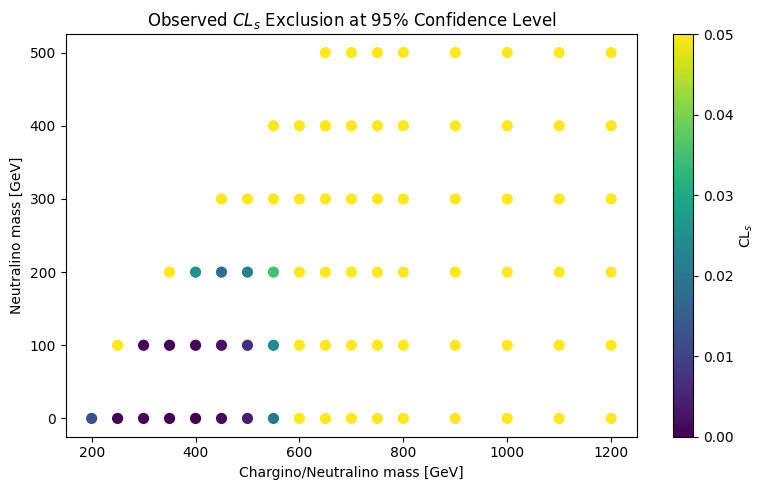

In [14]:
# create the figure
plt.figure(figsize=(8,5))

# create a scatter plot
plt.scatter(
    m_chargino,     # x-axis
    m_neutralino,   # y-axis
    c=CLs_obs,      # heatmap values
    cmap="viridis", # color of the heatmap
    vmin=0,         # smallest CL_s value on colorbar
    vmax=0.05,      # largest CL_s value on colorbar
    s=50            # point size
)

plt.colorbar(label="CL$_s$")                    # add color bar
plt.xlabel("Chargino/Neutralino mass [GeV]")    # x-axis label
plt.ylabel("Neutralino mass [GeV]")             # y-axis label
plt.title("Observed $CL_s$ Exclusion at 95% Confidence Level") # title

# display the plot
plt.tight_layout()
plt.show()

**What do you think?**
- Which points are excluded for our observed data using the $CL_s$ values?

Next, we draw a contour line, which is often how SUSY exclusion plots are visualized. We will use the ```tricontour``` function to plot a curve around our excluded points and overlay this contour on top of our scatter plot.


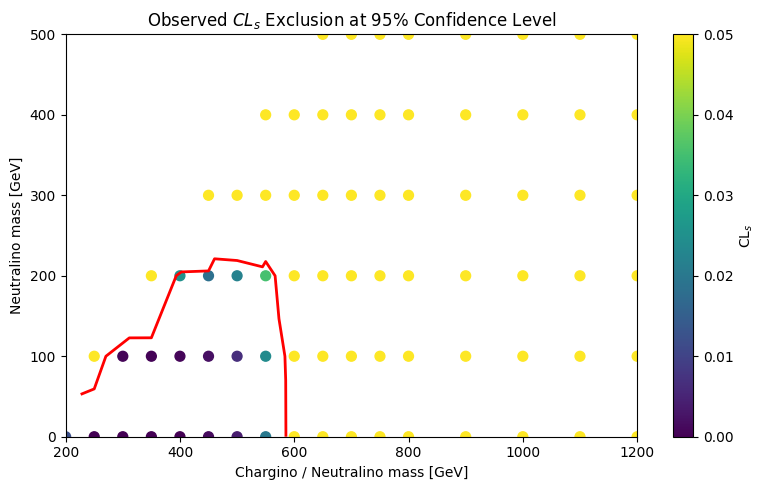

In [15]:
# create the figure
plt.figure(figsize=(8,5))

# plot contour line
plt.tricontour(
    m_chargino,    # x-axis
    m_neutralino,  # y-axis
    CLs_obs,       # what we are plotting
    levels=[0.05], # what values to plot contour at 95% CL = 0.05
    colors='red',  # color of the line
    linewidths=2   # width of the line
)

# create scatter plot
plt.scatter(
    m_chargino,     # x-axis
    m_neutralino,   # y-axis
    c=CLs_obs,      # heatmap values
    cmap="viridis", # color of the heatmap
    vmin=0,         # smallest CL_s value on colorbar
    vmax=0.05,      # largest CL_s value on colorbar
    s=50            # point size
)

plt.colorbar(label="CL$_s$")                    # add color bar
plt.xlabel("Chargino / Neutralino mass [GeV]")  # x-axis label
plt.ylabel("Neutralino mass [GeV]")             # y-axis label
plt.title("Observed $CL_s$ Exclusion at 95% Confidence Level")       # title

# display the plot
plt.tight_layout()
plt.show()

This makes it much easier to see which points we exclude. The red line surrounds all the points that are not yellow on the scatter plot, so any point inside the curve is excluded at the 95% confidence level.

**Try it yourself!** Go back to the calculation step and adjust the systematic uncertainty. Try setting it to zero or increasing it. How do the table values and the contour in the plot change?

# Calculating Expected Limits with the Asimov Dataset
In addition to the observed exclusion limit, we can compute expected limits. These describe the model assuming the data follows the background-only hypothesis. 

To compute the expected limits, we will use the Asimov dataset. The Asimov dataset represents the median expected outcome assuming a given hypothesis, typically the background-only hypothesis. This means we replace the observed number of events with the background yield:
$$n_i = b_i$$

Expected limits are often presented with uncertainty bands. By shifting the fitted signal strength by $\pm 1 \sigma$ around the median expected value, we obtain the expected variation in the exclusion limit. 

### Observed vs Expected Limits
The same likelihood, test statistics, and $CL_s$ calculations are used in both cases. The key difference between the two limits is the dataset we used:
- observed limits use the actual observed counts, $n_i$
- expected limits assume $ n_i = b_i$




In [35]:
# define expected CLs for Asimov dataset with plus minus 1 sigma shift
def CLs_expected(n_list, b_list, s_list, mu, b_stat_err_list, k):

    # use background-only Asimov dataset (mu=0)
    n_asimov = b_list.copy()

    # compute test statistic at mu=1 (curve of likelihood)
    q_1A = q_mu(n_asimov, b_list, s_list, 1.0, b_stat_err_list)

    if np.isnan(q_1A) or q_1A <= 1e-12: # avoid NaNs (set to small number)
        return np.nan

    # sigma: uncertainty on mu_hat under background-only
    sigma = 1.0 / np.sqrt(q_1A)

    # shifted mu_hat for plus/minus k * sigma
    mu_hat = k * sigma

    # likelihood test statistic for this mu_hat
    if mu_hat > mu:
        q_mu_val = 0.0
    else:
        q_mu_val = ((mu - mu_hat) ** 2) / sigma**2

    # Asimov q_mu (analytic form)
    q_mu_A = (mu ** 2) / sigma**2

    # Z values
    sqrt_q_mu = np.sqrt(max(q_mu_val, 0.0))
    sqrt_q_mu_A = np.sqrt(max(q_mu_A, 0.0))

    # numerator
    p_mu = norm.sf(sqrt_q_mu)

    # denominator 
    denominator = norm.cdf(sqrt_q_mu_A - sqrt_q_mu)

    if denominator <= 0: # avoid division by zero
        return np.nan

    return p_mu / denominator

In [36]:
# compute the median expected limits with pm 1 sigma band

# initialize lists to store computed results
CLs_exp =  []    # expected CLs
mu95_exp = []    # median signal strength
mu95_exp_p1 = [] # signal strength plus 1 sigma 
mu95_exp_m1 = [] # signal strength minus 1 sigma

# loop over each row in data frame
for _, row in df_data.iterrows():

    b_list = [row["background_highSR"],row["background_intSR"]]
    n_list = b_list.copy() # Aismov dataset: n_obs = background
    s_list = [row["signal_highSR"], row["signal_intSR"]]
    b_stat_err_list = [row["background_error_highSR"], row["background_error_intSR"]]

    # compute expected CLs for mu = 1 (median expected)
    mu_test = 1.0
    CLs_exp_val = CLs_expected(n_list, b_list, s_list, mu_test, b_stat_err_list, k=0.0)
    CLs_exp.append(CLs_exp_val)

    # compute 95% confidence level upper limit on signal strength (mu95)
    alpha = 0.05

    # function to find root: CLs(mu) - alpha = k
    def f(mu, k):
        return CLs_expected(n_list, b_list, s_list, mu, b_stat_err_list, k) - alpha

    # use root finder to find best value of mu
    try:
        mu95_median = brentq(lambda mu: f(mu, 0.0), 0.0, 1000.0) # median (k = 0)
    except ValueError:
        mu95_median = np.nan

    try:
        mu95_p1 = brentq(lambda mu: f(mu, +1.0), 0.0, 1000.0) # +1 sigma (k = 1)
    except ValueError:
        mu95_p1 = np.nan

    try:
        mu95_m1 = brentq(lambda mu: f(mu, -1.0), 0.0, 1000.0) # -1 sigma (k = -1)
    except ValueError:
        mu95_m1 = np.nan

    mu95_exp.append(mu95_median)
    mu95_exp_p1.append(mu95_p1)
    mu95_exp_m1.append(mu95_m1)

# add results to data frame
df_data["CLs_exp"] = CLs_exp
df_data["mu95_exp"] = mu95_exp
df_data["mu95_exp_p1"] = mu95_exp_p1
df_data["mu95_exp_m1"] = mu95_exp_m1


Similar to when we looked at the observed values, let’s pick the columns of the expected values in our data table:

In [37]:
# display our results
df_data[["m_chargino",
         "m_neutralino", 
         "CLs_exp",
         "mu95_exp",
        ]].head(15).round(3) # display first 15 rows, round to 3 decimal places

,m_chargino,m_neutralino,CLs_exp,mu95_exp
0,200.0,0.0,0.023,0.861
1,250.0,0.0,0.000,0.518
2,250.0,100.0,0.130,1.295
3,300.0,0.0,0.000,0.503
4,300.0,100.0,0.001,0.613
5,350.0,0.0,0.000,0.525
6,350.0,100.0,0.001,0.600
7,350.0,200.0,0.301,1.896
8,400.0,0.0,0.001,0.585
9,400.0,100.0,0.002,0.648


**Try it yourself!** Add the observed $CL_s$ and $\mu_{95}$ values to this table and compare the difference between the values.

**What do you think?**
- Are the expected $CL_s$ values different from the values in the observed limit? What about the signal strength parameter?
- Do these differences make sense with the values we are using? (Hint: Is our ```n_obs``` larger or smaller than our total background?)

# The Final Exclusion Contour Plot
Now that we have calculated both the observed and expected limits, we can plot them together tin an exclusion contour plot. Here, we will use the signal strength parameter instead of the $CL_s$ values, since it is the parameter that is typically used for plotting exclusion contours. The contour corresponds to $mu_{95}$ = 1.

To make the plot smoother than the previous ```tricontour``` method, we interpolate the values onto a grid using ```griddata```.

In this plot we will show:
- the observed exclusion limit as a solid red line
- the median expected exclusion limit as a dotted blue line
- The $\pm 1 \sigma$ uncertainty bands for the expected limits in yellow



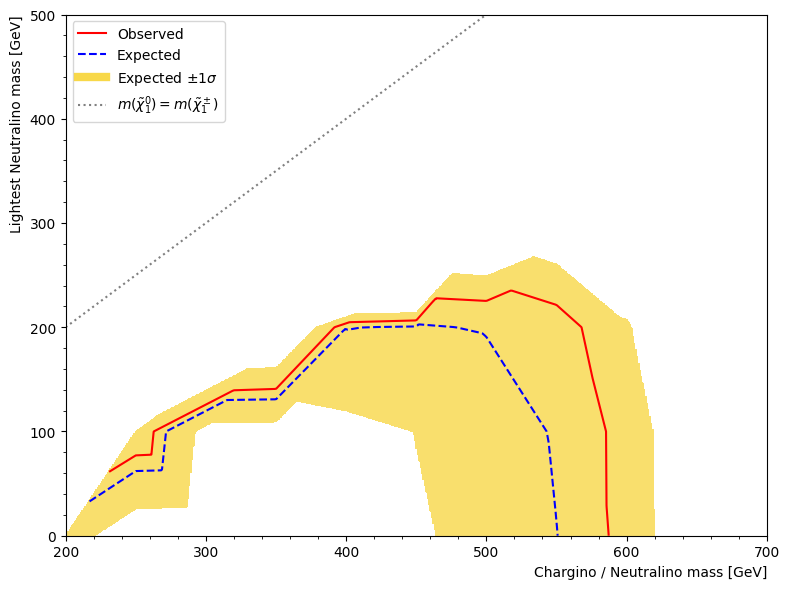

In [38]:
# convert lists to arrays for interpolation
m_chargino   = np.array(m_chargino)
m_neutralino = np.array(m_neutralino)
mu95_obs     = np.array(mu95_obs)
mu95_exp     = np.array(mu95_exp)
mu95_exp_p1  = np.array(mu95_exp_p1)
mu95_exp_m1  = np.array(mu95_exp_m1)

# create 2D grid for smooth contour plotting
chargino_grid   = np.linspace(m_chargino.min(), m_chargino.max(), 1000)
neutralino_grid = np.linspace(m_neutralino.min(), m_neutralino.max(), 1000)
chargino_mesh, neutralino_mesh = np.meshgrid(chargino_grid, neutralino_grid)

# interpolate mu95 values onto a 2D grid
method = 'linear'
rescale = True

mu95_obs_grid    = griddata((m_chargino, m_neutralino), mu95_obs,    (chargino_mesh, neutralino_mesh), method=method, rescale=rescale)
mu95_exp_grid    = griddata((m_chargino, m_neutralino), mu95_exp,    (chargino_mesh, neutralino_mesh), method=method, rescale=rescale)
mu95_exp_p1_grid = griddata((m_chargino, m_neutralino), mu95_exp_p1, (chargino_mesh, neutralino_mesh), method=method, rescale=rescale)
mu95_exp_m1_grid = griddata((m_chargino, m_neutralino), mu95_exp_m1, (chargino_mesh, neutralino_mesh), method=method, rescale=rescale)

# mask for +- 1 sigma expected band
band_mask = np.logical_and(mu95_exp_m1_grid <= 1.0, mu95_exp_p1_grid >= 1.0).astype(float)



# create the plot
fig, ax = plt.subplots(figsize=(8,6))

# fill in the expected band (dark yellow)
ax.contourf(chargino_mesh, neutralino_mesh, band_mask, levels=[0.5, 1.5], colors=['#f8d849'], alpha=0.8)

# plot expected(blue dotted) and observed (red solid) mu95=1 lines
ax.contour(chargino_mesh, neutralino_mesh, mu95_exp_grid, levels=[1.0], colors='blue', linestyles='--', linewidths=1.5)
ax.contour(chargino_mesh, neutralino_mesh, mu95_obs_grid, levels=[1.0], colors='red', linestyles='-', linewidths=1.5)

# diagonal line when chargino mass = neutralino mass (bounds on data)
ax.plot(chargino_grid, chargino_grid, color='grey', linestyle=':', linewidth=1.5)

# create a legend
exp_line    = mlines.Line2D([], [], color='blue',   linestyle='--', linewidth=1.5, label='Expected')
obs_line    = mlines.Line2D([], [], color='red',    linestyle='-',  linewidth=1.5, label='Observed')
band_line   = mlines.Line2D([], [], color='#f8d849', linestyle='-',  linewidth=6.0, label='Expected $\pm 1\sigma$')
bound_line  = mlines.Line2D([], [], color='grey',   linestyle=':',  linewidth=1.5, label= r'$m({\tilde{\chi}_1^0}) = m({\tilde{\chi}_1^\pm})$')
ax.legend(handles=[ obs_line, exp_line, band_line, bound_line], loc='upper left') # add legend to plot

# axes labels and limits
ax.set_xlim(200, 700)       # set limit on x-axis
ax.set_ylim(0, 500)         # set limit on y-axis
ax.minorticks_on()          # add smaller tick marks between numbers
ax.set_xlabel('Chargino / Neutralino mass [GeV]', loc='right') # x-axis label
ax.set_ylabel('Lightest Neutralino mass [GeV]', loc='top')     # y-axis label

# display the plot
plt.tight_layout()
plt.show()

In this plot, we see the same red contour line for our observed limits, and now a dotted line for the expected limits with the $\pm 1 \sigma$ uncertainty bands. We also show where the mass of the chargino $(m({\tilde{\chi}_1^0}))$ equals the mass of the neutralino $(m({\tilde{\chi}_1^\pm}))$ giving the boundary on our data.

**What do you think?**
- Do the expected and observed limits follow the same general shape?
- Why is the expected limit lower than the observed limit?
- Up to what mass values can we exclude at the 95% confidence level?

## Upper Limits on Cross Section and Signal Event Yields
This plot gives us an idea of what masses we can exclude in our limits. We can further quantify this and place upper limits on the cross sections.

We use the upper limit on the signal strength to determine the upper limit on the cross section:
$$ \sigma_{95} = \mu_{95} \cdot \sigma_{theory}$$

where
- $\sigma_{95}$ is the 95% upper limit on the cross section
- $\mu_{95}$ is the 95% upper limit on the signal strength
- $\sigma_{theory}$ is the theoretical cross section


In [39]:
# cross section
df_data["cross_section"] = df_data["cross_section"].values
cross_section = df_data["cross_section"].values

# observed cross section limit
sigma95_obs = mu95_obs * cross_section
df_data["sigma95_obs"] = sigma95_obs


# observed signal event yields limit
signal_yield_95_obs = np.array(mu95_obs) * (df_data["signal_highSR"].values + df_data["signal_intSR"].values)
df_data["signal_yield_95_obs"] = signal_yield_95_obs

# expected signal event yields limit
signal_yield_95_exp = np.array(mu95_exp) * (df_data["signal_highSR"].values + df_data["signal_intSR"].values)
df_data["signal_yield_95_exp"] = signal_yield_95_exp


Let's look at the 95% confidence upper limits on the cross section and the event yields for each of our signal models:

In [40]:
# display results
df_data[["m_chargino",
         "m_neutralino", 
    
         "sigma95_obs",
         
         "signal_yield_95_obs",
         "signal_yield_95_exp"

        ]].head(15).round(3) # print first 15 rows, round to 3 decimal places

,m_chargino,m_neutralino,sigma95_obs,signal_yield_95_obs,signal_yield_95_exp
0,200.0,0.0,1.189,4.304,5.633
1,250.0,0.0,0.202,4.290,8.623
2,250.0,100.0,0.955,4.311,4.573
3,300.0,0.0,0.089,4.257,9.350
4,300.0,100.0,0.138,4.307,7.404
5,350.0,0.0,0.050,3.988,8.788
6,350.0,100.0,0.067,4.159,7.810
7,350.0,200.0,0.416,4.314,4.119
8,400.0,0.0,0.035,3.810,7.694
9,400.0,100.0,0.043,3.840,7.029


**What do you think?**
- What do these upper limits on the cross sections tell us?
- How do the observed and expected signal yield limits compare to the expected signal yields from our analysis?

Since we have stored all our computed values in our data frame, we can easily look at any of these results for each signal model. These are our model-dependent limits, meaning they are upper limits for each individual signal model.

**Try it yourself!** Explore the results we have calculated. Compare the different values to see how the expected and observed limits differ, and how the upper limits compare to the expected event yields. 

# What's Next?
We have now completed a statistical analysis using real data from an ATLAS Open Data analysis searching for supersymmetric particles. This notebook provided a simplified approach to how we can implement likelihood methods with an asymptotic Frequentist framework and determine exclusion statistics.

Here are a few suggestions of what else you can explore:
- **Compare Results:** How do your results compare to published analyses? Are they similar or different for the same physics model?
- **Use your data:** Run this analysis with your own data and results.
- **Try a one-dimensional analysis:** Focus on a single variable, for example cross section vs mass, number of events vs mass.
- **Implement toy models:** Instead of relying on the asymptotic approximation, try generating toy datasets to calculate upper limits.
- **Frequentist vs Bayesian:** These methods focus on the Frequentist approach; explore how a Bayesian approach might differ.
